# AI-Based Phishing URL Detection — STEP 6: Train/Test Split & Baseline Model

Notebook ini memakai hasil feature engineering dari STEP 5 untuk mulai proses modeling.

**Cara pakai:**
- Pastikan `data/processed/phishing_features.csv` sudah ada (hasil dari `02_feature_engineering.ipynb`).

## 1. Load Data Hasil Feature Engineering

In [1]:
import pandas as pd

features_df = pd.read_csv('../data/processed/phishing_features.csv')
print("Shape:", features_df.shape)
features_df.head()

Shape: (507080, 9)


,url_length,dot_count,digit_count,hyphen_count,special_char_count,has_at_symbol,subdomain_count,has_ip_address,Label
0,225,6,58,4,16,0,0,0,bad
1,81,5,1,2,6,0,1,0,bad
2,177,7,47,1,1,0,0,0,bad
3,60,6,0,0,0,0,1,0,bad
4,116,1,21,1,2,0,0,0,bad


## 2. Train/Test Split (Stratified)

Membagi data 80:20 dengan `stratify=y` supaya proporsi label ('good' vs 'bad') sama persis antara train dan test set — penting untuk evaluasi yang adil dan representatif.

In [2]:
from sklearn.model_selection import train_test_split

X = features_df.drop(columns='Label')  # semua fitur
y = features_df['Label']               # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("\nProporsi label di y_train:")
print(y_train.value_counts(normalize=True))
print("\nProporsi label di y_test:")
print(y_test.value_counts(normalize=True))

X_train: (405664, 8)  X_test: (101416, 8)

Proporsi label di y_train:
Label
good    0.774693
bad     0.225307
Name: proportion, dtype: float64

Proporsi label di y_test:
Label
good    0.77469
bad     0.22531
Name: proportion, dtype: float64


## 3. Baseline Model — Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scaling fitur — WAJIB untuk Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit HANYA di train
X_test_scaled = scaler.transform(X_test)          # transform test pakai parameter dari train

# Training baseline model
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred = baseline_model.predict(X_test_scaled)

# Evaluasi awal (sederhana dulu — evaluasi lengkap di STEP berikutnya)
from sklearn.metrics import accuracy_score
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))

Baseline Accuracy: 0.832393310720202


In [4]:
%matplotlib inline

              precision    recall  f1-score   support

         bad       0.85      0.31      0.45     22850
        good       0.83      0.98      0.90     78566

    accuracy                           0.83    101416
   macro avg       0.84      0.65      0.68    101416
weighted avg       0.84      0.83      0.80    101416

Confusion Matrix:
[[ 7051 15799]
 [ 1199 77367]]


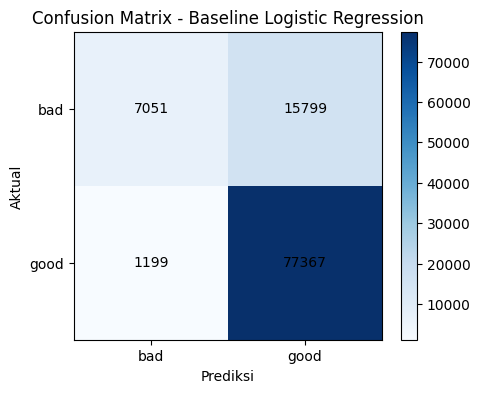


ROC-AUC: 0.7542305149676662


In [5]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Classification report: precision, recall, F1 per kelas
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['bad', 'good'])
print("Confusion Matrix:")
print(cm)

# Visualisasi confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['bad', 'good'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['bad', 'good'])
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar(im)
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.show()

# ROC-AUC (butuh probability, bukan cuma kelas prediksi)
y_proba = baseline_model.predict_proba(X_test_scaled)[:, list(baseline_model.classes_).index('good')]
y_test_binary = (y_test == 'good').astype(int)
print("\nROC-AUC:", roc_auc_score(y_test_binary, y_proba))

In [6]:
# Baseline model kedua: Logistic Regression dengan class_weight='balanced'
model_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)

print(classification_report(y_test, y_pred_balanced, target_names=['bad', 'good']))

cm_balanced = confusion_matrix(y_test, y_pred_balanced, labels=['bad', 'good'])
print("Confusion Matrix:")
print(cm_balanced)

y_proba_balanced = model_balanced.predict_proba(X_test_scaled)[:, list(model_balanced.classes_).index('good')]
print("\nROC-AUC:", roc_auc_score(y_test_binary, y_proba_balanced))

              precision    recall  f1-score   support

         bad       0.42      0.63      0.50     22850
        good       0.87      0.74      0.80     78566

    accuracy                           0.72    101416
   macro avg       0.64      0.69      0.65    101416
weighted avg       0.77      0.72      0.73    101416

Confusion Matrix:
[[14330  8520]
 [20196 58370]]

ROC-AUC: 0.7553357096078498


In [7]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree dengan max_depth dibatasi untuk cegah overfitting,
# dan class_weight='balanced' (pelajaran dari eksperimen sebelumnya)
dtree = DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced')
dtree.fit(X_train, y_train)  # tidak perlu X_train_scaled — Decision Tree tidak butuh scaling
y_pred_dtree = dtree.predict(X_test)

print(classification_report(y_test, y_pred_dtree, target_names=['bad', 'good']))

cm_dtree = confusion_matrix(y_test, y_pred_dtree, labels=['bad', 'good'])
print("Confusion Matrix:")
print(cm_dtree)

y_proba_dtree = dtree.predict_proba(X_test)[:, list(dtree.classes_).index('good')]
print("\nROC-AUC:", roc_auc_score(y_test_binary, y_proba_dtree))

# Cek overfitting: bandingkan accuracy train vs test
from sklearn.metrics import accuracy_score
print("\nTrain accuracy:", accuracy_score(y_train, dtree.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, y_pred_dtree))

# Feature importance
importances = pd.Series(dtree.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

              precision    recall  f1-score   support

         bad       0.55      0.73      0.62     22850
        good       0.91      0.83      0.87     78566

    accuracy                           0.80    101416
   macro avg       0.73      0.78      0.75    101416
weighted avg       0.83      0.80      0.81    101416

Confusion Matrix:
[[16582  6268]
 [13709 64857]]

ROC-AUC: 0.8648613235796511

Train accuracy: 0.807069397333754
Test accuracy: 0.8030192474560227

Feature Importances:
dot_count             0.317316
digit_count           0.236350
url_length            0.182465
special_char_count    0.149655
hyphen_count          0.057854
subdomain_count       0.044736
has_ip_address        0.008576
has_at_symbol         0.003048
dtype: float64


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    max_depth=15,        # sedikit lebih dalam dari Decision Tree tunggal — wajar untuk ensemble
    n_estimators=200,    # jumlah pohon
    class_weight='balanced',
    n_jobs=-1             # pakai semua core CPU untuk mempercepat training
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=['bad', 'good']))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['bad', 'good'])
print("Confusion Matrix:")
print(cm_rf)

y_proba_rf = rf.predict_proba(X_test)[:, list(rf.classes_).index('good')]
print("\nROC-AUC:", roc_auc_score(y_test_binary, y_proba_rf))

print("\nTrain accuracy:", accuracy_score(y_train, rf.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, y_pred_rf))

importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances_rf)

              precision    recall  f1-score   support

         bad       0.59      0.75      0.66     22850
        good       0.92      0.85      0.88     78566

    accuracy                           0.82    101416
   macro avg       0.75      0.80      0.77    101416
weighted avg       0.84      0.82      0.83    101416

Confusion Matrix:
[[17079  5771]
 [12084 66482]]

ROC-AUC: 0.8924254931017036

Train accuracy: 0.8338896229391812
Test accuracy: 0.8239429675790803

Feature Importances:
digit_count           0.257268
url_length            0.216535
dot_count             0.208352
special_char_count    0.129140
hyphen_count          0.098014
subdomain_count       0.068172
has_ip_address        0.015331
has_at_symbol         0.007188
dtype: float64


                                Accuracy  Precision (bad)  Recall (bad)  \
Model                                                                     
Logistic Regression (balanced)    0.7168           0.4150        0.6271   
Decision Tree                     0.8030           0.5474        0.7257   
Random Forest                     0.8239           0.5856        0.7474   

                                F1 (bad)  ROC-AUC  
Model                                              
Logistic Regression (balanced)    0.4995   0.7553  
Decision Tree                     0.6241   0.8649  
Random Forest                     0.6567   0.8924  


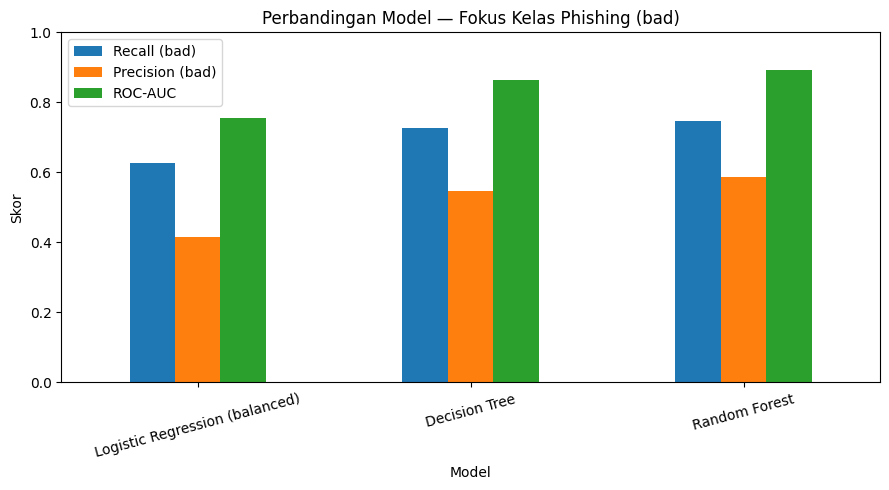

In [9]:
# Cara lebih rapi: hitung langsung dari classification_report sebagai dict
from sklearn.metrics import classification_report

reports = {
    'Logistic Regression (balanced)': classification_report(y_test, y_pred_balanced, output_dict=True),
    'Decision Tree': classification_report(y_test, y_pred_dtree, output_dict=True),
    'Random Forest': classification_report(y_test, y_pred_rf, output_dict=True),
}

roc_aucs = {
    'Logistic Regression (balanced)': roc_auc_score(y_test_binary, y_proba_balanced),
    'Decision Tree': roc_auc_score(y_test_binary, y_proba_dtree),
    'Random Forest': roc_auc_score(y_test_binary, y_proba_rf),
}

comparison = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision (bad)': report['bad']['precision'],
        'Recall (bad)': report['bad']['recall'],
        'F1 (bad)': report['bad']['f1-score'],
        'ROC-AUC': roc_aucs[name],
    }
    for name, report in reports.items()
])

comparison = comparison.set_index('Model').round(4)
print(comparison)

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 5))
comparison[['Recall (bad)', 'Precision (bad)', 'ROC-AUC']].plot(kind='bar', ax=ax)
ax.set_title('Perbandingan Model — Fokus Kelas Phishing (bad)')
ax.set_ylabel('Skor')
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

comparison.to_csv('../reports/model_comparison.csv')

Model Export

In [10]:
import joblib

joblib.dump(rf, '../models/random_forest_phishing.joblib')
print("Model tersimpan di ../models/random_forest_phishing.joblib")

Model tersimpan di ../models/random_forest_phishing.joblib
